# BE 447 Final Project

This notebook uses a reusable `DatasetClassifier` class for preprocessing, hyperparameter tuning, and evaluation on the breast cancer survival dataset.

That way we can easily test with different models and params with minimal code rewriting.

## Imports

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


## Load Primary Dataset

In [52]:
# load in the data and turn it into a 
bcsd_df = pd.read_csv("breast_cancer_survival.csv")
print(f"Dataset shape: {bcsd_df.shape}")
print("Missing target labels:", bcsd_df["Patient_Status"].isna().sum())
print(bcsd_df.columns.tolist())
bcsd_df.head()

Dataset shape: (334, 15)
Missing target labels: 13
['Age', 'Gender', 'Protein1', 'Protein2', 'Protein3', 'Protein4', 'Tumour_Stage', 'Histology', 'ER status', 'PR status', 'HER2 status', 'Surgery_type', 'Date_of_Surgery', 'Date_of_Last_Visit', 'Patient_Status']


,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


## Dataset Classifier Class

In [ ]:
class DatasetClassifier:
    # Future expansion: I plan to add more models here once we can test that this class works.
    SUPPORTED_MODELS = {"svc"}
    SUPPORTED_NUMERIC_IMPUTERS = {"mean", "median", "mode"}
    # Future expansion: add date encoding once the model is trained with dropping. See if date encodeing improves classification
    # or adds insight to the data
    SUPPORTED_DATE_STRATEGIES = {"drop"}

    
    def __init__(
        self,
        data,
        target_column,
        model_name="svc",
        numeric_impute_strategy="median",
        categorical_impute_strategy="mode",
        date_columns=None,
        date_strategy="drop",
        scoring="f1_weighted",
        train_size=0.6,
        val_size=0.2,
        test_size=0.2,
        random_state=42,
        custom_param_grid=None,
    ):
        
        # instance member variables
        self.data = data
        self.target_column = target_column
        self.model_name = model_name
        self.numeric_impute_strategy = numeric_impute_strategy
        self.categorical_impute_strategy = categorical_impute_strategy
        self.date_columns = date_columns or []
        self.date_strategy = date_strategy
        self.scoring = scoring
        self.train_size = train_size
        self.val_size = val_size
        self.test_size = test_size
        self.random_state = random_state
        self.custom_param_grid = custom_param_grid

        # user params error section
        # We need to verify that the test training and validation sets sum up to 1 for full data
        total = train_size + val_size + test_size
        if not np.isclose(total, 1.0):
            raise ValueError("train_size + val_size + test_size must equal 1.0")
        # verify if the passed model is supported
        if model_name not in self.SUPPORTED_MODELS:
            raise ValueError(f"Unsupported model_name: {model_name}")
        # Verify if the numeric and categorical impute strategies are supported
        if numeric_impute_strategy not in self.SUPPORTED_NUMERIC_IMPUTERS:
            raise ValueError(
                "numeric_impute_strategy must be one of "
                f"{sorted(self.SUPPORTED_NUMERIC_IMPUTERS)}"
            )
        if categorical_impute_strategy != "mode":
            raise ValueError("Manual categorical imputation only supports 'mode'")
        # Verify if the date strategy is supported currently only drop. 
        if date_strategy not in self.SUPPORTED_DATE_STRATEGIES:
            raise ValueError(
                f"date_strategy must be one of {sorted(self.SUPPORTED_DATE_STRATEGIES)}"
            )
        
        # define dictionaries to hold the classification and confusion statistics
        self.report_texts_ = {}
        self.report_dicts_ = {}
        self.confusion_matrices_ = {}

    # load the dataset as a csv, then convert it into a dataframe
    def _load_dataframe(self):
        # If data passed is already a dataframe, create a copy and return the copy
        if isinstance(self.data, pd.DataFrame):
            return self.data.copy()
        return pd.read_csv(self.data)

    # Currently we drop the date columns with this member
    def _apply_date_strategy(self, df):
        # create a copy of the dataframe to not alter the original
        df = df.copy()
        valid_date_columns = [col for col in self.date_columns if col in df.columns]
        # Future expansion: I want to encode dates into numeric features instead of dropping them. to see if we can get insight on the results
        return df.drop(columns=valid_date_columns)

    # This member imputes or fills the null data points in the selected way
    def impute(self, X, fit=False):
        X = X.copy()

        if fit:
            self.fill_values_ = {}

            for col in X.columns:
                non_null_values = []

                for val in X[col]:
                    if pd.notna(val):
                        non_null_values.append(val)

                if len(non_null_values) == 0:
                    if col in self.numeric_columns_:
                        self.fill_values_[col] = 0.0
                    else:
                        self.fill_values_[col] = "Missing"
                    continue

                if col in self.numeric_columns_:
                    if self.numeric_impute_strategy == "mean":
                        running_sum = 0
                        count = 0
                        for val in non_null_values:
                            running_sum += val
                            count += 1
                        self.fill_values_[col] = running_sum / count
                    elif self.numeric_impute_strategy == "median":
                        sorted_values = sorted(non_null_values)
                        n = len(sorted_values)
                        mid = n // 2
                        if n % 2 == 0:
                            self.fill_values_[col] = (sorted_values[mid - 1] + sorted_values[mid]) / 2
                        else:
                            self.fill_values_[col] = sorted_values[mid]
                    else:
                        value_counts = {}
                        for val in non_null_values:
                            value_counts[val] = value_counts.get(val, 0) + 1
                        self.fill_values_[col] = max(value_counts, key=value_counts.get)
                else:
                    value_counts = {}
                    for val in non_null_values:
                        value_counts[val] = value_counts.get(val, 0) + 1
                    self.fill_values_[col] = max(value_counts, key=value_counts.get)

        applicable_fill_values = {}
        for col in self.fill_values_:
            if col in X.columns:
                applicable_fill_values[col] = self.fill_values_[col]
        return X.fillna(applicable_fill_values)

    def encode(self, X, fit=False):
        encoded = pd.get_dummies(
            X,
            columns=self.categorical_columns_,
            dtype=float,
        )

        if fit:
            self.encoded_columns_ = encoded.columns.tolist()

        encoded = encoded.reindex(columns=self.encoded_columns_, fill_value=0.0)
        return encoded

    def scale(self, X, fit=False):
        X = X.copy()

        if fit:
            self.scaled_numeric_columns_ = []
            for col in self.numeric_columns_:
                if col in X.columns:
                    self.scaled_numeric_columns_.append(col)

            if self.scaled_numeric_columns_:
                self.scaler_ = StandardScaler()
                self.scaler_.fit(X[self.scaled_numeric_columns_])
            else:
                self.scaler_ = None

        if self.scaler_ is not None and self.scaled_numeric_columns_:
            for col in self.scaled_numeric_columns_:
                X[col] = X[col].astype(float)

            scaled_values = self.scaler_.transform(X[self.scaled_numeric_columns_])
            scaled_df = pd.DataFrame(
                scaled_values,
                columns=self.scaled_numeric_columns_,
                index=X.index,
            )

            for col in self.scaled_numeric_columns_:
                X[col] = scaled_df[col]

        return X

    def prepare_data(self):
        df = self._load_dataframe()
        # REplace any whitespace cells with nan values
        df = df.replace(r"^\s*$", np.nan, regex=True)

        
        if self.target_column not in df.columns:
            raise ValueError(f"Target column '{self.target_column}' was not found")

        df = df.dropna(subset=[self.target_column]).reset_index(drop=True)
        df = self._apply_date_strategy(df)

        X = df.drop(columns=[self.target_column])
        y = df[self.target_column]

        self.numeric_columns_ = X.select_dtypes(include=np.number).columns.tolist()
        self.categorical_columns_ = [
            col for col in X.columns if col not in self.numeric_columns_
        ]
        self.feature_columns_ = X.columns.tolist()
        self.class_labels_ = sorted(y.unique().tolist())

        test_size = self.val_size + self.test_size
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            stratify=y,
            random_state=self.random_state,
        )

        relative_test_size = self.test_size / test_size
        X_val, X_test, y_val, y_test = train_test_split(
            X_test,
            y_test,
            test_size=relative_test_size,
            stratify=y_test,
            random_state=self.random_state,
        )

        self.X_train = X_train.reset_index(drop=True)
        self.X_val = X_val.reset_index(drop=True)
        self.X_test = X_test.reset_index(drop=True)
        self.y_train = y_train.reset_index(drop=True)
        self.y_val = y_val.reset_index(drop=True)
        self.y_test = y_test.reset_index(drop=True)

        self.X_train = self.impute(self.X_train, fit=True)
        self.X_val = self.impute(self.X_val)
        self.X_test = self.impute(self.X_test)

        self.X_train_prepared = self.encode(self.X_train, fit=True)
        self.X_val_prepared = self.encode(self.X_val)
        self.X_test_prepared = self.encode(self.X_test)

        self.X_train_prepared = self.scale(self.X_train_prepared, fit=True)
        self.X_val_prepared = self.scale(self.X_val_prepared)
        self.X_test_prepared = self.scale(self.X_test_prepared)
        self.prepared_ = True
        return self

    # get the model and param grid that was passed to the class
    def _get_model_and_param_grid(self):
        # create a dictionary of dictionaries to hold the default param grids
        default_grids = {
            "svc": {
                "kernel": ["linear", "rbf"],
                "C": [0.1, 1, 10],
                "gamma": ["scale", "auto"],
            },
            # Future expansion: add parameter grids for additional classifiers here.
        }

        # Current version only builds an SVC model.
        model = SVC(class_weight="balanced", random_state=self.random_state)

        # Save the custom param grid if it has a value, if not use default
        param_grid = self.custom_param_grid or default_grids[self.model_name]
        return model, param_grid

    def _get_split_data(self, split):
        split_map = {
            "train": (self.X_train_prepared, self.y_train),
            "val": (self.X_val_prepared, self.y_val),
            "test": (self.X_test_prepared, self.y_test),
        }
        if split not in split_map:
            raise ValueError("split must be one of: 'train', 'val', 'test'")
        return split_map[split]

    def fit(self):
        if not getattr(self, "prepared_", False):
            self.prepare_data()

        model, param_grid = self._get_model_and_param_grid()
        X_search = pd.concat([self.X_train_prepared, self.X_val_prepared], axis=0).reset_index(drop=True)
        y_search = pd.concat([self.y_train, self.y_val], axis=0).reset_index(drop=True)
        # Use stratified k-fold during grid search so each fold keeps a similar
        # class balance while the test split stays untouched for final evaluation.
        self.cv_strategy_ = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=self.random_state,
        )

        self.grid_search_ = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=self.cv_strategy_,
            scoring=self.scoring,
            n_jobs=-1,
            refit=True,
            return_train_score=True,
        )
        self.grid_search_.fit(X_search, y_search)

        self.best_estimator_ = self.grid_search_.best_estimator_
        self.best_params_ = self.grid_search_.best_params_
        self.validation_score_ = self.grid_search_.best_score_
        self.test_predictions_ = self.best_estimator_.predict(self.X_test_prepared)
        return self

    def predict(self, split="test"):
        #self._check_is_fitted()
        X_split, _ = self._get_split_data(split)
        return self.best_estimator_.predict(X_split)

    def classification_report(self, split="test"):
        #self._check_is_fitted()
        _, y_true = self._get_split_data(split)
        y_pred = self.predict(split=split)

        report_text = classification_report(
            y_true,
            y_pred,
            labels=self.class_labels_,
            zero_division=0,
        )
        report_dict = classification_report(
            y_true,
            y_pred,
            labels=self.class_labels_,
            zero_division=0,
            output_dict=True,
        )

        self.report_texts_[split] = report_text
        self.report_dicts_[split] = report_dict
        print(report_text)
        return report_text

    def confusion_matrix(self, split="test", normalize=None, plot=True):
        #self._check_is_fitted()
        _, y_true = self._get_split_data(split)
        y_pred = self.predict(split=split)

        matrix = confusion_matrix(
            y_true,
            y_pred,
            labels=self.class_labels_,
            normalize=normalize,
        )
        self.confusion_matrices_[split] = matrix

        if plot:
            value_format = ".2f" if normalize is not None else "d"
            fig, ax = plt.subplots(figsize=(6, 6))
            display = ConfusionMatrixDisplay(
                confusion_matrix=matrix,
                display_labels=self.class_labels_,
            )
            display.plot(ax=ax, cmap="Blues", values_format=value_format, colorbar=False)
            ax.set_title(f"{self.model_name} confusion matrix ({split})")
            plt.show()

        return matrix

    def summarize_results(self):
        #self._check_is_fitted()
        summary = pd.DataFrame(
            [
                {
                    "model_name": self.model_name,
                    "numeric_impute_strategy": self.numeric_impute_strategy,
                    "categorical_impute_strategy": self.categorical_impute_strategy,
                    "date_strategy": self.date_strategy,
                    "scoring": self.scoring,
                    "validation_best_score": self.validation_score_,
                    "test_accuracy": accuracy_score(self.y_test, self.test_predictions_),
                    "test_f1_weighted": f1_score(
                        self.y_test,
                        self.test_predictions_,
                        average="weighted",
                    ),
                    "best_params": str(self.best_params_),
                }
            ]
        )
        display(summary)
        return summary


## Baseline Run

The baseline model uses SVC with median imputation for numeric columns and drops the date columns to avoid leakage from follow-up information.

Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


,model_name,numeric_impute_strategy,categorical_impute_strategy,date_strategy,scoring,validation_best_score,test_accuracy,test_f1_weighted,best_params
0,svc,median,mode,drop,balanced_accuracy,0.629884,0.569231,0.598763,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}"


              precision    recall  f1-score   support

       Alive       0.77      0.65      0.70        51
        Dead       0.18      0.29      0.22        14

    accuracy                           0.57        65
   macro avg       0.47      0.47      0.46        65
weighted avg       0.64      0.57      0.60        65



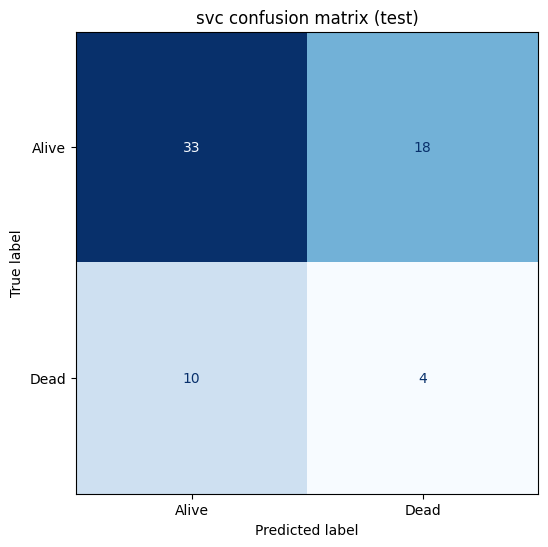

,model_name,numeric_impute_strategy,categorical_impute_strategy,date_strategy,scoring,validation_best_score,test_accuracy,test_f1_weighted,best_params
0,svc,median,mode,drop,balanced_accuracy,0.629884,0.569231,0.598763,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}"


In [ ]:
baseline_clf = DatasetClassifier(
    data="breast_cancer_survival.csv",
    target_column="Patient_Status",
    model_name="svc",
    numeric_impute_strategy="median",
    date_columns=["Date_of_Surgery", "Date_of_Last_Visit"],
    date_strategy="drop",
    scoring="balanced_accuracy",
)

baseline_clf.fit()
print("Best parameters:", baseline_clf.best_params_)
baseline_summary = baseline_clf.summarize_results()
baseline_clf.classification_report(split="test")
baseline_clf.confusion_matrix(split="test", normalize=None, plot=True)
baseline_summary